In [1]:
pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install "numpy<2"

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 792.4 kB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


Количество рисинок: 100


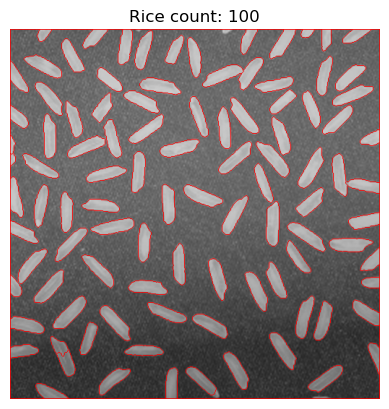

In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Загрузка
img = cv2.imread('/Users/230271/rice.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl = clahe.apply(gray)

# 2. Otsu threshold
_, thresh = cv2.threshold(cl, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Morphological opening (удаление шума)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# 4. Distance transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 255, 0)

# 5. Найти фон
sure_fg = np.uint8(sure_fg)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

unknown = cv2.subtract(sure_bg, sure_fg)

# 6. Маркеры
_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

# Watershed
markers = cv2.watershed(img, markers)

# Границы
img[markers == -1] = [0, 0, 255]

# Подсчёт (игнорируем фон и границы)
rice_count = len(np.unique(markers)) - 2

print("Количество рисинок:", rice_count)

# Визуализация
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Rice count: {rice_count}")
plt.axis('off')
plt.show()